[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/02_Supervised_classification/decision_trees.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

### Decision Trees

A decision tree predicts by asking a sequence of yes/no questions about the features ("is $x_3 \le 0.7$?"), sending each sample down to a **leaf** whose training samples decide the prediction: the majority class for classification, or the mean target for regression.

Training is **greedy recursive partitioning**. At each node, try every feature and every threshold, keep the split that makes the two children as *pure* as possible, then recurse until a stopping rule fires.

Theory: [Decision Trees](README.md#decision-trees)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

from mlf_utils import check_agreement, check_close, plot_decision_regions

sns.set_theme(style="whitegrid")
np.random.seed(42)

#### Impurity measures
For a node whose samples have class proportions $p_1, \dots, p_K$:

$$\large \text{Gini}(p) = 1 - \sum_{k} p_k^2 \qquad\qquad \text{Entropy}(p) = -\sum_{k} p_k \log_2 p_k$$

Both are 0 for a pure node and largest for a 50/50 mix. A split's quality is the **impurity decrease** (information gain for entropy), weighted by child size:

$$\large \Delta = I(\text{parent}) - \frac{n_L}{n} I(\text{left}) - \frac{n_R}{n} I(\text{right})$$

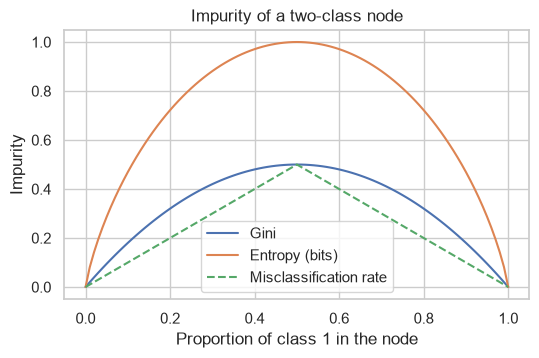

In [3]:
def gini(counts):
    p = counts / counts.sum(axis=-1, keepdims=True)
    return 1.0 - (p ** 2).sum(axis=-1)

def entropy(counts):
    p = counts / counts.sum(axis=-1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        return -np.where(p > 0, p * np.log2(p), 0.0).sum(axis=-1)

p = np.linspace(0, 1, 101)
counts = np.stack([p, 1 - p], axis=1)
plt.figure(figsize=(6, 3.5))
plt.plot(p, gini(counts), label="Gini")
plt.plot(p, entropy(counts), label="Entropy (bits)")
plt.plot(p, 1 - np.maximum(p, 1 - p), label="Misclassification rate", ls="--")
plt.xlabel("Proportion of class 1 in the node"); plt.ylabel("Impurity"); plt.legend()
plt.title("Impurity of a two-class node")
plt.show()

#### A decision tree from scratch
**Finding the best split efficiently.** For one feature, sort the samples by that feature once. Every possible threshold then splits the sorted list into a prefix (left) and a suffix (right), and a **cumulative sum** of one-hot labels gives the class counts of every prefix at once. That gives an $O(n \log n)$ search per feature instead of $O(n^2)$. Thresholds are placed halfway between consecutive distinct values, the same convention scikit-learn uses.

**Stopping rules:** the node is pure, it has fewer than `min_samples_split` samples, it reached `max_depth`, or no split leaves at least `min_samples_leaf` samples on both sides.

In [4]:
class Node:
    def __init__(self, counts, impurity, depth):
        self.counts, self.impurity, self.depth = counts, impurity, depth
        self.feature = self.threshold = self.left = self.right = None

    @property
    def is_leaf(self):
        return self.left is None


class ScratchDecisionTree:
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.impurity_fn = {"gini": gini, "entropy": entropy}[criterion]
        self.max_depth, self.min_samples_split, self.min_samples_leaf = max_depth, min_samples_split, min_samples_leaf

    def fit(self, X, y):
        self.n_classes_, self.n_features_ = int(y.max()) + 1, X.shape[1]
        self.n_samples_ = len(y)
        self.importances_ = np.zeros(self.n_features_)
        self.root_ = self._grow(X, y, depth=0)
        self.feature_importances_ = self.importances_ / self.importances_.sum()
        return self

    def _best_split(self, X, y):
        n = len(y)
        best = (np.inf, None, None)                        # (weighted child impurity, feature, threshold)
        onehot = np.eye(self.n_classes_)[y]
        n_left = np.arange(1, n)                           # split after position i -> i+1 samples on the left
        n_right = n - n_left
        for j in range(self.n_features_):
            order = np.argsort(X[:, j], kind="stable")
            xs = X[order, j]
            left_counts = np.cumsum(onehot[order], axis=0)[:-1]
            right_counts = left_counts[-1] + onehot[order][-1] - left_counts
            child_impurity = (n_left * self.impurity_fn(left_counts) + n_right * self.impurity_fn(right_counts)) / n
            valid = (xs[1:] > xs[:-1]) & (n_left >= self.min_samples_leaf) & (n_right >= self.min_samples_leaf)
            if not valid.any():
                continue
            child_impurity = np.where(valid, child_impurity, np.inf)
            i = int(np.argmin(child_impurity))
            if child_impurity[i] < best[0]:
                threshold = (xs[i] + xs[i + 1]) / 2.0
                if threshold == xs[i + 1]:                 # guard against float rounding at the midpoint
                    threshold = xs[i]
                best = (child_impurity[i], j, threshold)
        return best

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_).astype(float)
        node = Node(counts, self.impurity_fn(counts), depth)
        if (node.impurity <= 1e-12 or len(y) < self.min_samples_split
                or (self.max_depth is not None and depth >= self.max_depth)):
            return node
        child_impurity, feature, threshold = self._best_split(X, y)
        if feature is None:
            return node
        node.feature, node.threshold = feature, threshold
        go_left = X[:, feature] <= threshold
        # impurity decrease weighted by the fraction of all training samples in this node
        self.importances_[feature] += len(y) / self.n_samples_ * (node.impurity - child_impurity)
        node.left = self._grow(X[go_left], y[go_left], depth + 1)
        node.right = self._grow(X[~go_left], y[~go_left], depth + 1)
        return node

    def _leaf(self, x):
        node = self.root_
        while not node.is_leaf:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node

    def predict_proba(self, X):
        return np.array([self._leaf(x).counts / self._leaf(x).counts.sum() for x in X])

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    # --- introspection helpers ---
    def _nodes(self, node=None):
        node = node or self.root_
        yield node
        if not node.is_leaf:
            yield from self._nodes(node.left)
            yield from self._nodes(node.right)

    def get_depth(self):
        return max(n.depth for n in self._nodes())

    def get_n_leaves(self):
        return sum(n.is_leaf for n in self._nodes())

    def print_tree(self, feature_names=None, node=None, indent=""):
        node = node or self.root_
        if node.is_leaf:
            print(f"{indent}predict {int(node.counts.argmax())}  (samples={int(node.counts.sum())}, counts={node.counts.astype(int).tolist()})")
            return
        name = feature_names[node.feature] if feature_names else f"x{node.feature}"
        print(f"{indent}if {name} <= {node.threshold:.3f}:   (gini/entropy={node.impurity:.3f}, samples={int(node.counts.sum())})")
        self.print_tree(feature_names, node.left, indent + "    ")
        print(f"{indent}else:")
        self.print_tree(feature_names, node.right, indent + "    ")

#### Data: a 3-class problem
scikit-learn trees work in **float32** internally, so we use float32 data too. That way both implementations see exactly the same candidate thresholds.

In [5]:
X_np, y_np = make_classification(n_samples=600, n_features=6, n_informative=4, n_redundant=1,
                                 n_classes=3, n_clusters_per_class=1, random_state=0)
X_np = X_np.astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.3, random_state=42)

tree = ScratchDecisionTree(max_depth=3).fit(X_train, y_train)
tree.print_tree()
print(f"\nTest accuracy (depth 3): {np.mean(tree.predict(X_test) == y_test):.3f}")

if x3 <= 0.318:   (gini/entropy=0.665, samples=420)
    if x0 <= 0.230:   (gini/entropy=0.562, samples=287)
        if x5 <= -0.288:   (gini/entropy=0.470, samples=178)
            predict 0  (samples=73, counts=[27, 19, 27])
        else:
            predict 0  (samples=105, counts=[96, 0, 9])
    else:
        if x5 <= 0.825:   (gini/entropy=0.137, samples=109)
            predict 2  (samples=102, counts=[1, 1, 100])
        else:
            predict 0  (samples=7, counts=[6, 0, 1])
else:
    if x5 <= 1.308:   (gini/entropy=0.323, samples=133)
        if x4 <= -0.417:   (gini/entropy=0.205, samples=122)
            predict 2  (samples=19, counts=[1, 8, 10])
        else:
            predict 1  (samples=103, counts=[0, 100, 3])
    else:
        predict 0  (samples=11, counts=[11, 0, 0])

Test accuracy (depth 3): 0.822


#### Verifying against scikit-learn
For both criteria and several depths, our tree should grow the same tree as `DecisionTreeClassifier`: the same depth and number of leaves, and the same **total leaf impurity** $\\sum_{\\text{leaves}} \\frac{n_\\ell}{n} I(\\ell)$, which is the quantity the greedy algorithm minimises.

One subtlety: deep in the tree, a split often isolates just one or two samples, and several *different* features can do that **equally well** (an exact tie). scikit-learn breaks ties by visiting features in a random order, and ours takes the lowest feature index. The trees are then equally good but credit different features, so predictions can differ slightly and feature importances noticeably. We therefore require identical importances only for the shallow tree, where there are no ties.

In [6]:
def total_leaf_impurity_ours(tree):
    return sum(n.counts.sum() * n.impurity for n in tree._nodes() if n.is_leaf) / tree.n_samples_

def total_leaf_impurity_sklearn(sk):
    t = sk.tree_
    leaves = t.children_left == -1
    return (t.n_node_samples[leaves] * t.impurity[leaves]).sum() / t.n_node_samples[0]

for criterion in ["gini", "entropy"]:
    for max_depth in [2, 4, None]:
        ours = ScratchDecisionTree(criterion=criterion, max_depth=max_depth).fit(X_train, y_train)
        sk = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=0).fit(X_train, y_train)
        tag = f"[{criterion}, max_depth={max_depth}]"
        check_close(f"{tag} depth / leaves", [ours.get_depth(), ours.get_n_leaves()], [sk.get_depth(), sk.get_n_leaves()])
        check_close(f"{tag} total leaf impurity", total_leaf_impurity_ours(ours), total_leaf_impurity_sklearn(sk), atol=1e-6)
        check_agreement(f"{tag} test predictions", ours.predict(X_test), sk.predict(X_test), min_agreement=0.97)
        if max_depth == 2:
            check_close(f"{tag} feature importances", ours.feature_importances_, sk.feature_importances_, atol=1e-6)

print("\nFeature importances, max_depth=4 (gini). The tied splits credit different features:")
print("  ours:   ", ScratchDecisionTree(max_depth=4).fit(X_train, y_train).feature_importances_.round(3))
print("  sklearn:", DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train).feature_importances_.round(3))

✓ [gini, max_depth=2] depth / leaves: matches (max |diff| = 0.00e+00)
✓ [gini, max_depth=2] total leaf impurity: matches (max |diff| = 5.55e-17)
✓ [gini, max_depth=2] test predictions: 100.0% agreement
✓ [gini, max_depth=2] feature importances: matches (max |diff| = 1.67e-16)
✓ [gini, max_depth=4] depth / leaves: matches (max |diff| = 0.00e+00)
✓ [gini, max_depth=4] total leaf impurity: matches (max |diff| = 4.16e-17)
✓ [gini, max_depth=4] test predictions: 100.0% agreement
✓ [gini, max_depth=None] depth / leaves: matches (max |diff| = 0.00e+00)
✓ [gini, max_depth=None] total leaf impurity: matches (max |diff| = 0.00e+00)
✓ [gini, max_depth=None] test predictions: 98.3% agreement
✓ [entropy, max_depth=2] depth / leaves: matches (max |diff| = 0.00e+00)
✓ [entropy, max_depth=2] total leaf impurity: matches (max |diff| = 0.00e+00)
✓ [entropy, max_depth=2] test predictions: 100.0% agreement
✓ [entropy, max_depth=2] feature importances: matches (max |diff| = 5.55e-17)
✓ [entropy, max_depth=

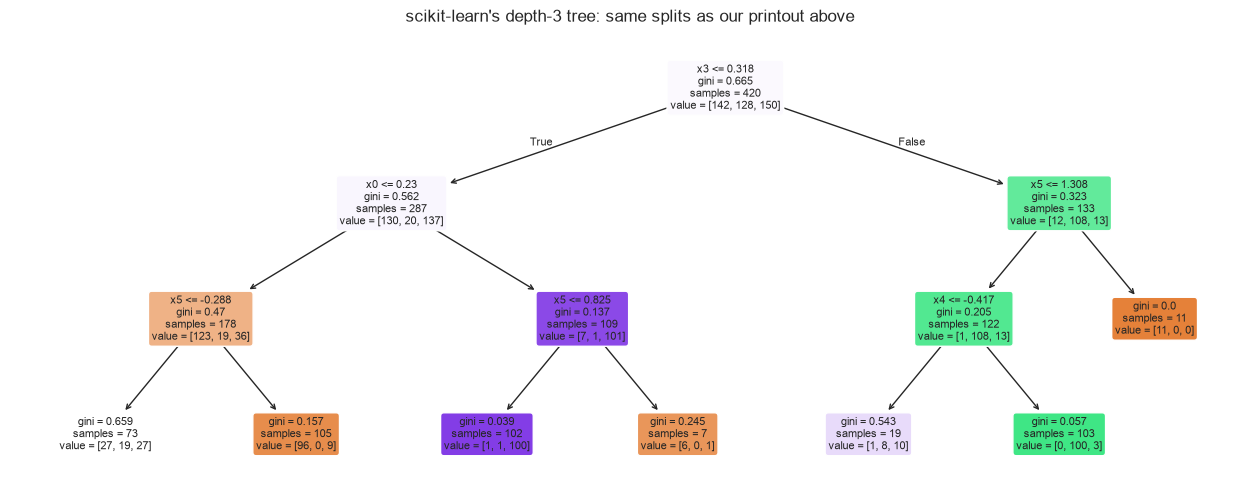

In [7]:
sk_small = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
plt.figure(figsize=(16, 6))
plot_tree(sk_small, filled=True, rounded=True, fontsize=8, feature_names=[f"x{i}" for i in range(X_np.shape[1])])
plt.title("scikit-learn's depth-3 tree: same splits as our printout above")
plt.show()

#### Overfitting: depth controls complexity
An unrestricted tree keeps splitting until every leaf is pure, which means it memorises the training set (100% training accuracy) including its noise. Shallow trees underfit. Depth, `min_samples_leaf` and pruning are the knobs.

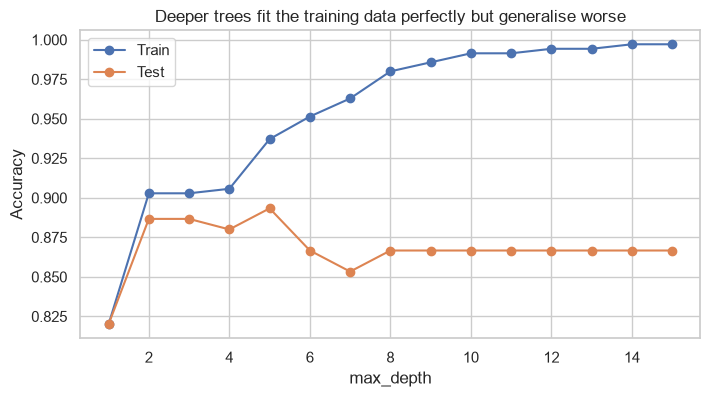

In [8]:
Xm, ym = make_moons(n_samples=500, noise=0.3, random_state=42)
Xm = Xm.astype(np.float32)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.3, random_state=42)

depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    t = ScratchDecisionTree(max_depth=d).fit(Xm_train, ym_train)
    train_acc.append(np.mean(t.predict(Xm_train) == ym_train))
    test_acc.append(np.mean(t.predict(Xm_test) == ym_test))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_acc, "o-", label="Train"); plt.plot(depths, test_acc, "o-", label="Test")
plt.xlabel("max_depth"); plt.ylabel("Accuracy"); plt.legend()
plt.title("Deeper trees fit the training data perfectly but generalise worse")
plt.show()

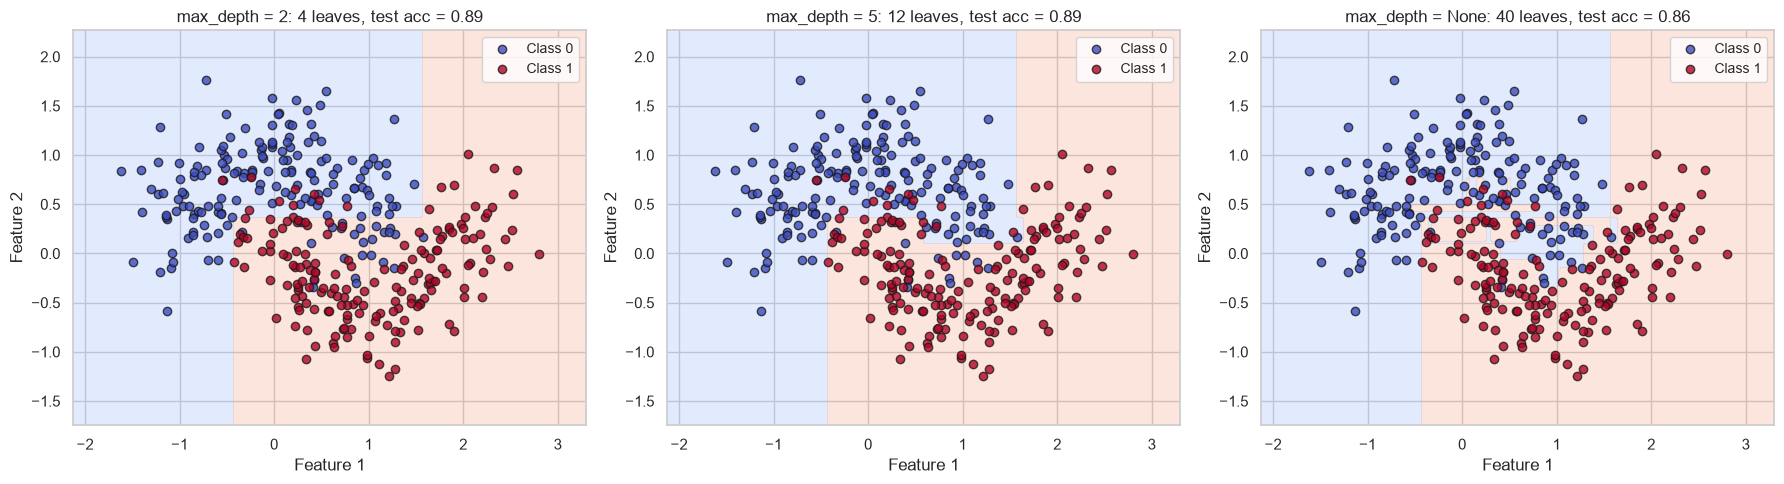

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, d in zip(axes, [2, 5, None]):
    t = ScratchDecisionTree(max_depth=d).fit(Xm_train, ym_train)
    plot_decision_regions(t.predict, Xm_train, ym_train, ax=ax, resolution=150,
                          title=f"max_depth = {d}: {t.get_n_leaves()} leaves, test acc = {np.mean(t.predict(Xm_test) == ym_test):.2f}")
plt.tight_layout()
plt.show()

Tree boundaries are always **axis-aligned** rectangles, because every split looks at one feature. A diagonal boundary needs a staircase of many splits, which is one reason ensembles of trees work so much better than a single tree.

#### Try it: tree depth and leaf size
`max_depth` limits how many questions the tree may ask. `min_samples_leaf` forbids tiny leaves, which is an effective way to stop the tree chasing individual noisy points.

*Interactive: run the notebook locally or in Colab to use the controls. GitHub only renders a static page.*

In [10]:
from ipywidgets import IntSlider, interact

@interact(max_depth=IntSlider(value=4, min=1, max=15, continuous_update=False),
          min_samples_leaf=IntSlider(value=1, min=1, max=50, continuous_update=False))
def explore_tree(max_depth, min_samples_leaf):
    t = ScratchDecisionTree(max_depth=max_depth, min_samples_leaf=min_samples_leaf).fit(Xm_train, ym_train)
    plot_decision_regions(t.predict, Xm_train, ym_train, resolution=150,
                          title=f"depth {t.get_depth()}, {t.get_n_leaves()} leaves | train acc = "
                                f"{np.mean(t.predict(Xm_train) == ym_train):.2f}, test acc = {np.mean(t.predict(Xm_test) == ym_test):.2f}")
    plt.show()

interactive(children=(IntSlider(value=4, continuous_update=False, description='max_depth', max=15, min=1), Int…

#### Cost-complexity pruning
Instead of stopping early, grow a full tree and then **prune** it back. Cost-complexity pruning minimises

$$\large R_\alpha(T) = R(T) + \alpha \, |\text{leaves}(T)|$$

where $R(T)$ is the total leaf impurity. Increasing $\alpha$ removes the weakest branches first. scikit-learn computes the whole sequence of pruned trees with `cost_complexity_pruning_path`, and we pick $\alpha$ by validation accuracy.

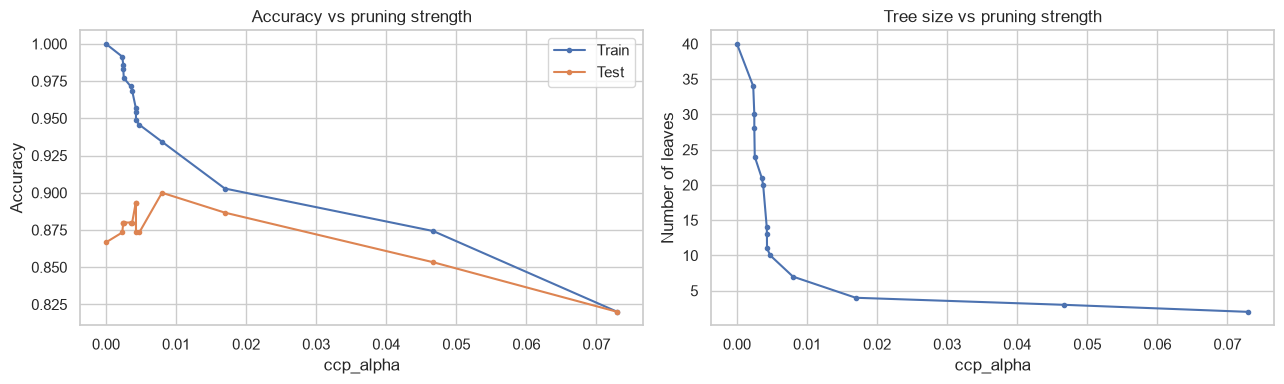

In [11]:
path = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(Xm_train, ym_train)
alphas = path.ccp_alphas[:-1]                    # the last alpha prunes down to the root
pruned = [DecisionTreeClassifier(random_state=0, ccp_alpha=a).fit(Xm_train, ym_train) for a in alphas]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(alphas, [m.score(Xm_train, ym_train) for m in pruned], "o-", ms=3, label="Train")
axes[0].plot(alphas, [m.score(Xm_test, ym_test) for m in pruned], "o-", ms=3, label="Test")
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].set_title("Accuracy vs pruning strength")
axes[1].plot(alphas, [m.get_n_leaves() for m in pruned], "o-", ms=3)
axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("Number of leaves"); axes[1].set_title("Tree size vs pruning strength")
plt.tight_layout()
plt.show()

#### Regression trees
For a continuous target, the impurity is the **variance** (MSE) of the node's targets, and each leaf predicts the **mean** of its samples. The result is a piecewise-constant function: deeper trees make finer steps and eventually fit the noise.

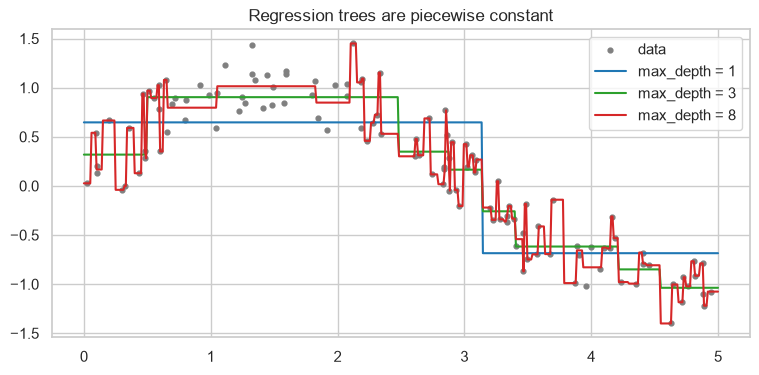

In [12]:
rng = np.random.RandomState(0)
x_reg = np.sort(rng.uniform(0, 5, 120)).reshape(-1, 1)
y_reg = np.sin(x_reg).ravel() + rng.normal(0, 0.25, 120)
x_grid = np.linspace(0, 5, 500).reshape(-1, 1)

plt.figure(figsize=(9, 4))
plt.scatter(x_reg, y_reg, s=12, color="gray", label="data")
for d, color in [(1, "tab:blue"), (3, "tab:green"), (8, "tab:red")]:
    reg = DecisionTreeRegressor(max_depth=d, random_state=0).fit(x_reg, y_reg)
    plt.plot(x_grid, reg.predict(x_grid), color=color, label=f"max_depth = {d}")
plt.legend(); plt.title("Regression trees are piecewise constant")
plt.show()

#### Summary
| | Decision tree |
|---|---|
| Strengths | Interpretable (for small trees), no feature scaling needed, handles mixed feature types and non-linear interactions, fast prediction |
| Weaknesses | High variance (small data changes produce a different tree), axis-aligned boundaries, greedy (not globally optimal), overfits without limits |
| Key hyperparameters | `max_depth`, `min_samples_leaf`, `min_samples_split`, `ccp_alpha`, `criterion` |
| Fix for the variance | Average many trees: see [ensembles](ensembles.ipynb) |